# Introduction

## Introduction to the domain-specific area 

Emotion analysis in text has become increasingly important in domains such as digital mental health, social media monitoring, conversational AI, and customer feedback systems. Traditional sentiment analysis typically classifies text as positive, negative, or neutral, or in some cases identifies a single emotion label. However, real-world language is rarely that simple people often express multiple emotions at once. For instance, a single post might convey both sadness and anger, or hope alongside fear. This complexity has driven interest in multi-label emotion classification, which allows multiple emotions to be assigned to a single text input.

Despite the emotional richness of language, much of the existing literature and industry practice still focuses on single-label classification. Studies such as those by Bostan and Klinger (Bostan Bostan et al., 2018) have highlighted this limitation, noting that human emotional expression is multifaceted and context-dependent. In response, multi-label classification frameworks have emerged as a more realistic and powerful approach to capturing emotional nuance.

Multi-label emotion classification poses distinct challenges. Unlike single-label tasks, models must learn not only how to identify individual emotions but also how to recognize and handle their co-occurrence. This often requires handling class imbalance, where certain emotions (like "joy" or "neutral") appear much more frequently than others (like "grief" or "remorse"). Additionally, many traditional classifiers, especially statistical models, assume independence between labels, which can limit their ability to model emotional overlap effectively.

On the other hand, recent advances in deep learning, particularly with models using word embeddings and convolutional or recurrent neural networks offer promising alternatives. These models can learn latent semantic relationships and are more flexible in recognizing and capturing emotion patterns across different contexts(Jadon & Kumar, n.d.). However, they also come with trade-offs in terms of interpretability, training time, and the need for more data(Stihec, 2024).

Given this evolving landscape, it becomes essential to ask: how well do different model types perform on real-world multi-label emotion classification tasks? Answering this question not only contributes to the academic field of natural language processing (NLP) but also provides practical insights for building systems that need to understand human emotion more holistically.

This study is situated within this domain, aiming to explore the effectiveness of different modeling approaches both traditional and modern in recognizing multiple emotional labels from textual data. It reflects a growing recognition that emotion is rarely singular and that capturing its complexity is crucial for building more human-centric and responsive AI systems.


## Objectives

Building on the premise that emotional expression in language is complex and multi-dimensional, the core objective of this study is to evaluate and compare the performance of different text classification models in handling multi-label emotion detection. This project seeks to empirically test how well various modelling paradigms including statistical and deep learning methods perform when applied to a real-world, imbalanced, and multi-label dataset: GoEmotions.

The study evaluates three models:

  -	A baseline Multinomial Naive Bayes classifier using Bag-of-Words features

  -	A statistical model using Logistic Regression with TF-IDF weighting

  -	A modern deep learning model combining pre-trained GloVe embeddings with a Convolutional Neural Network (CNN)

Each model represents a step forward in terms of feature sophistication and architectural complexity. By comparing them side-by-side on the same task, the study aims to determine whether the added computational and data requirements of deep learning architectures are justified by significant improvements in predictive performance for multi-label emotion tasks.

The central research question is: To what extent do deep learning models outperform traditional statistical models in multilabel emotion classification, particularly under conditions of class imbalance and label co-occurrence?

Another key goal of the project is to assess the practical trade-offs between the interpretability and efficiency of statistical models versus the performance and semantic richness of embedding-based architectures. While CNNs with pre-trained embeddings are expected to better capture contextual emotional patterns, they also introduce complexity in terms of tuning, threshold optimization, and reduced transparency in decision-making. By quantifying the performance gap across models and analyzing these trade-offs, the project contributes a more nuanced understanding of the conditions under which each modeling approach is most appropriate.

In summary, this project provides a comparative evaluation of traditional and modern methods for multi-label emotion classification. The results will help clarify whether deep learning architectures offer enough performance gain to justify their added complexity, and under what conditions simpler models may still suffice. To ensure a balanced comparison, model performance will be analyzed not only in aggregate but also across the full emotional spectrum from frequently occurring emotions to rare, nuanced ones. This understanding is essential for researchers and developers working in sentiment and emotion recognition, particularly when deploying models in settings where computational resources, interpretability, or data availability are constrained.


## Dataset Description

This project uses the GoEmotions dataset, a large-scale, human-annotated dataset developed by researchers at Google for fine-grained emotion classification. GoEmotions is particularly well-suited for this study, as it supports multi-label classification, which directly aligns with the objective of analyzing multiple emotional complexity,

The dataset comprises 58,000 English Reddit comments sourced from diverse subreddits and topics, ensuring broad domain coverage. Each comment is annotated with one or more emotions selected from a taxonomy of 27 emotion labels such as joy, sadness, anger, fear, disappointment, excitement, pride, and more. Additionally, a “neutral” label is included for emotionally unmarked texts. 

One of the distinguishing characteristics of GoEmotions is that each comment can be tagged with multiple emotions, enabling the modeling of nuanced emotional co-occurrence. For example, a single comment may simultaneously express both grief and anger, reflecting real-world linguistic behavior where emotional states overlap.

The dataset is structured as a CSV file and includes the following key columns:

  -	text: the original Reddit comment (data type: string)

  -	id, author, subreddit, link_id, parent_id: metadata columns used to provide context(data type: string)

  -	created_utc: timestamp of the comment (data type: integer or datetime)

  -	rater_id: identifies the annotator (data type: integer)

  -	example_very_unclear: a binary flag indicating annotation uncertainty (data type: boolean)

  -	Followed by 28 binary columns, each corresponding to an emotion label (e.g., admiration, joy, fear, ..., neutral). These columns indicate whether the label was assigned (1) or not (0) by a given rate

For the purposes of this project, only a subset of the available columns is used. Specifically, the text column is used as the input for classification, while the 28 binary emotion columns serve as the target labels in the multi-label task. The example_very_unclear boolean flag is also retained to optionally filter out samples where annotators expressed uncertainty. The remaining metadata fields such as id, author, subreddit, link_id, parent_id, created_utc, and rater_id are excluded from modeling, as they do not contribute directly to the emotion classification objective.

The dataset is publicly available and can be accessed through Google’s GitHub repository:
https://github.com/google-research/google-research/tree/master/goemotions

Overall, GoEmotions is highly appropriate for this project. Its diverse emotional range, multi-label annotations, and real-world textual data make it an ideal benchmark for testing the strengths and limitations of different classification models, from traditional statistical learners to modern embedding-based deep learning architectures.


## Evaluation Methodology

In this project, the evaluation of model performance relies on multiple metrics tailored to the multi-label and highly imbalanced nature of the GoEmotions dataset. Traditional accuracy is not used as a primary evaluation metric, as it can be misleading in multilabel contexts. For example, a model might appear to perform well by predicting only the most frequent emotions, which would inflate accuracy despite poor detection of rare or nuanced emotional expressions.

Instead, the analysis focuses on precision, recall, and F1-score, using both micro and macro averaging:

  - Micro-averaged metrics aggregate the contributions of all classes, giving more weight to high-frequency labels like neutral or approval. They are helpful for assessing overall model performance across all predictions.

  - Macro-averaged metrics compute the metric for each label independently and average them. This ensures that rare emotions such as grief, remorse, or embarrassment are treated equally, offering a more balanced evaluation across the emotional spectrum.

Given the aim of this project to fairly assess how well each model captures both common and rare emotions, macro F1-score is used as the primary evaluation metric when comparing models.

Each model is evaluated using:
  - A summary table reports the micro and macro precision, recall, and F1-scores. These aggregated metrics offer a snapshot of overall model performance across all emotion categories.

  - A detailed classification report is also generated, breaking down the metrics per emotion label. This helps identify how well each model handles both common and rare classes. For instance, a label with high precision but low recall suggests that the model is conservative only predicting that emotion when highly confident whereas labels with low scores across all metrics may be underrepresented or lack distinct features in the text.
  
  - Precision-recall (PR) curves are used instead of ROC-AUC plots, since ROC curves often appear overly optimistic in imbalanced scenarios due to an overrepresentation of true negatives. PR curves, in contrast, focus only on the positive class and are more informative for rare labels, showing how well precision and recall trade off across decision thresholds.

Confusion matrices are not used for evaluation. In multilabel classification, where multiple labels can be correct for a single input, confusion matrices lose interpretive clarity especially as there is no single predicted class per instance. Instead, per-label classification reports and PR curves provide more meaningful insight into individual label performance.

Finally, once all individual model evaluations are completed, results are aggregated using visualizations. Radar charts summarize precision, recall, and F1-scores across micro and macro scales, while grouped bar charts compare aggregate metrics taken from the classification report like macro, weighted, and sample-average F1-scores. Replacing the PR curve for better visualization, a scatter plot of F1-score versus support per emotion is used to illustrate how well each model performs across both common and rare emotions. This graph provides nuanced insight into model strengths. These graphs enable side-by-side comparisons and help identify performance differences clearly, without relying on confusing tabular outputs.

This multi-faceted evaluation approach ensures a fair and comprehensive assessment of each model’s ability to handle the complexities of multilabel emotion detection.


# Implementation

## Data Preprocessing

### Loading of dataset

The GoEmotions dataset is downloaded from GitHub and stored locally in a structured directory. This ensures reproducibility and avoids manual data handling

In [1]:
import os
import urllib.request

# Create target directory
os.makedirs("data/full_dataset", exist_ok=True)

# List of files to download
urls = [
    "https://storage.googleapis.com/gresearch/goemotions/data/full_dataset/goemotions_1.csv",
    "https://storage.googleapis.com/gresearch/goemotions/data/full_dataset/goemotions_2.csv",
    "https://storage.googleapis.com/gresearch/goemotions/data/full_dataset/goemotions_3.csv"
]

# Download loop
for i, url in enumerate(urls, start=1):
    filename = f"data/full_dataset/goemotions_{i}.csv"
    if not os.path.exists(filename):
        print(f"Downloading {filename}...")
        urllib.request.urlretrieve(url, filename)
    else:
        print(f"{filename} already exists.")


data/full_dataset/goemotions_1.csv already exists.
data/full_dataset/goemotions_2.csv already exists.
data/full_dataset/goemotions_3.csv already exists.


After downloading the three parts of the dataset, each CSV file was loaded into memory using pandas and then concatenated into a single dataframe. Combining the files into one large dataset simplifies analysis and processing.

In [2]:
import pandas as pd

# Read all CSVs and concatenate
dfs = [
    pd.read_csv(f"data/full_dataset/goemotions_{i}.csv")
    for i in range(1, 4)
]
df = pd.concat(dfs, ignore_index=True)

# Check the data
print(df.shape)
df.head()


(211225, 37)


,text,id,author,subreddit,link_id,parent_id,created_utc,rater_id,example_very_unclear,admiration,...,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral
0,That game hurt.,eew5j0j,Brdd9,nrl,t3_ajis4z,t1_eew18eq,1.548381e+09,1,False,0,...,0,0,0,0,0,0,0,1,0,0
1,>sexuality shouldn’t be a grouping category I...,eemcysk,TheGreen888,unpopularopinion,t3_ai4q37,t3_ai4q37,1.548084e+09,37,True,0,...,0,0,0,0,0,0,0,0,0,0
2,"You do right, if you don't care then fuck 'em!",ed2mah1,Labalool,confessions,t3_abru74,t1_ed2m7g7,1.546428e+09,37,False,0,...,0,0,0,0,0,0,0,0,0,1
3,Man I love reddit.,eeibobj,MrsRobertshaw,facepalm,t3_ahulml,t3_ahulml,1.547965e+09,18,False,0,...,1,0,0,0,0,0,0,0,0,0
4,"[NAME] was nowhere near them, he was by the Fa...",eda6yn6,American_Fascist713,starwarsspeculation,t3_ackt2f,t1_eda65q2,1.546669e+09,2,False,0,...,0,0,0,0,0,0,0,0,0,1


### Text Cleaning

A custom cleaning function was implemented to preprocess the raw Reddit comment text. This function standardizes the input by performing several transformations, including converting all characters to lowercase, removing URLs, punctuation, brackets, digits, and excessive whitespace. These steps help to reduce textual noise and remove irrelevant symbols that do not contribute meaningfully to the classification task. By ensuring that the data is clean and consistently formatted, the preprocessing stage improves the quality of downstream feature extraction, whether through statistical methods like TF-IDF or embedding-based approaches. This prepares the text for more effective and accurate emotion classification.

In [3]:
import re
def clean_text(text):
    # converting all the text to lower case
    text = text.lower()
    # removing any urls
    text = re.sub(r"http\S+|www\S+|https\S+", '', text)
    # removing the text inside square brackets
    text = re.sub(r'\[.*?\]', '', text)  
    # removing the brackets itself
    text = re.sub(r'[()\[\]{}<>]', '', text) 
    # removing mentions and hashtags
    text = re.sub(r'\@w+|\#','', text)
    # removing punctuations
    text = re.sub(r'[^\w\s]', '', text) 
    # removing digits
    text = re.sub(r'\d+', '', text) 
    # remove the white space if any 
    text = re.sub(r'\s+', ' ', text).strip()
    return text

The cleaning function was then applied to the original text column to produce a new column of cleaned text for further processing.

In [4]:
# Apply the cleaning function to a new column
df['cleaned_text'] = df['text'].apply(clean_text)


In [5]:
# side by side comparison of the cleaned and uncleaned text
df[['text', 'cleaned_text']].head()

,text,cleaned_text
0,That game hurt.,that game hurt
1,>sexuality shouldn’t be a grouping category I...,sexuality shouldnt be a grouping category it m...
2,"You do right, if you don't care then fuck 'em!",you do right if you dont care then fuck em
3,Man I love reddit.,man i love reddit
4,"[NAME] was nowhere near them, he was by the Fa...",was nowhere near them he was by the falcon


### Handling missing and duplicate text

The dataset was then further cleaned by removing any rows with missing values in the text column and dropping duplicate text entries. Rows with missing text were removed because they do not provide any meaningful input for training or evaluation. Duplicate entries were also dropped to ensure that only unique text samples are used, which helps prevent the model from learning biased or repeated patterns. These cleaning steps contribute to improving the overall quality and reliability of the dataset.

In [6]:
# Drop rows with missing text
df = df.dropna(subset=['text'])

# Drop duplicate text rows
df = df.drop_duplicates(subset=['text'])


### Normalization: Tokenization and Lemmatization

In natural language processing, text normalization is a critical preprocessing step that aims to reduce linguistic variability and improve consistency in textual data. For this project, normalization is especially important because emotion classification depends on identifying semantically similar words that may appear in different grammatical forms (e.g. “loved”, “loving”, and “love” should be treated the same). To perform normalization techniques such as lemmatization, the text must first be tokenized split into individual word units called tokens. Tokenization transforms each text string into a list of words, allowing subsequent operations to be applied at the word level. In this project, tokenization was carried out using NLTK’s word_tokenize function.

In [7]:
import nltk
nltk.download('punkt')
from nltk.tokenize import word_tokenize

df['tokens'] = df['cleaned_text'].apply(word_tokenize)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\gohji\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


After tokenization, the next step in text normalization is to reduce each word to its simplest form. This can be done using two common techniques: stemming and lemmatization. Stemming removes word endings using simple rules, but the results are often not real words (for example, “happily” becomes “happi”). Lemmatization, on the other hand, looks up each word in a dictionary to find its proper base form (for example, “running” becomes “run”). In this project, lemmatization was chosen because it keeps the words meaningful and easier to interpret. This is especially important for emotion classification, where understanding the actual word meaning helps the model perform better. NLTK’s WordNetLemmatizer was used to apply lemmatization to each word in the dataset.

In [8]:
nltk.download('wordnet')
from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()

# Apply lemmatization to each token in the list
df['lemmatized_tokens'] = df['tokens'].apply(
    lambda tokens: [lemmatizer.lemmatize(word) for word in tokens]
)

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\gohji\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [9]:
# comparing tokens to lemmatised tokens
df[['tokens', 'lemmatized_tokens']].head()


,tokens,lemmatized_tokens
0,"[that, game, hurt]","[that, game, hurt]"
1,"[sexuality, shouldnt, be, a, grouping, categor...","[sexuality, shouldnt, be, a, grouping, categor..."
2,"[you, do, right, if, you, dont, care, then, fu...","[you, do, right, if, you, dont, care, then, fu..."
3,"[man, i, love, reddit]","[man, i, love, reddit]"
4,"[was, nowhere, near, them, he, was, by, the, f...","[wa, nowhere, near, them, he, wa, by, the, fal..."


### Stopword Removal


Stop words are common words in English that often appear frequently but don’t carry much unique meaning such as 'the'. For statistical models such as Bag of Words and TF-IDF,which rely on frequency-based representation of words, stop words were removed from the lemmatized tokens to reduce noise and eliminate irrelevant features. This step allows the model to focus on more informative, emotion-related terms, which may enhance its ability to learn meaningful patterns for classification.

After removing stop words, the remaining tokens were joined back into strings. This is necessary because the TF-IDF vectorizer and Count Vectorizer in scikit-learn expects raw text input rather than lists of tokens. By joining the cleaned, lemmatized tokens into space-separated strings, the text becomes suitable for vectorization, allowing the model to be trained

In [ ]:
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

# Remove stopwords from the lemmatized tokens
df['lemmatized_tokens_nostop'] = df['lemmatized_tokens'].apply(
    lambda tokens: [word for word in tokens if word not in stop_words]
)

# Join back into string for TF-IDF/ count vectorizer input
df['text_for_stat'] = df['lemmatized_tokens_nostop'].apply(lambda x: ' '.join(x))


In contrast, embedding-based models like the CNN with GloVe handle data differently, using word vectors rather than frequency features. These differences in data preparation will be discussed in more detail in the section describing the modern model architecture.

### Dropping of redundant columns

To maintain the integrity and consistency of the training data, all rows marked as "example_very_unclear" were removed. These entries reflect comments that annotators found difficult to interpret, and their inclusion could compromise model learning from inconsistent labeling. Following this, several columns unrelated to the classification task were dropped. These included metadata fields (e.g., author ID, subreddit, timestamps) and intermediary preprocessing columns (e.g., tokens, lemmatized tokens) that are no longer needed. This results in a streamlined dataset containing only the preprocessed input text and corresponding emotion labels, ready for vectorization and training

In [11]:
df_stat = df.copy()
df_stat = df_stat[df_stat['example_very_unclear'] != True]
columns_to_drop = [
    'text','id', 'author', 'subreddit', 'link_id', 'parent_id', 'created_utc',
    'rater_id', 'example_very_unclear', 'tokens',
    'lemmatized_tokens', 'lemmatized_tokens_nostop', 'cleaned_text'
]

df_stat.drop(columns=columns_to_drop, inplace=True)
df_stat


,admiration,amusement,anger,annoyance,approval,caring,confusion,curiosity,desire,disappointment,...,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral,text_for_stat
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,game hurt
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,right dont care fuck em
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,man love reddit
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,wa nowhere near wa falcon
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,right considering important document know damn...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211086,1,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,called steelers wa outspoken good juju pick wa
211088,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,didnt even notice one noticed bottom right one
211094,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,thanks
211095,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,everyone like


### Features and label preparation

The processed text (text_for_stat) was assigned to X as the input data, while all remaining emotion columns were retained in y as the multi-label targets for classification.

In [ ]:
# X is the input text
X = df_stat['text_for_stat']

# y is everything else (all emotion columns)
y = df_stat.drop(columns=['text_for_stat'])

### Train-test split

To evaluate the performance of the classification models, the dataset was split into training and testing sets using an 80/20 ratio. This means 80% of the data was used to train the models, while the remaining 20% was held out for evaluation. This approach ensures that the model is trained on a sufficiently large dataset while retaining a separate, unseen portion of the data to assess generalization performance.

In [13]:
from sklearn.model_selection import train_test_split

# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=22
)

## Baseline Performance

In this project, the Bag-of-Words (BoW) representation was used in combination with Multinomial Naive Bayes (MNB) as the baseline model. This combination was selected due to its simplicity, interpretability, and well-established effectiveness in text classification tasks. BoW converts each document into a vector of word occurrence counts, making it a natural fit for MNB, which is designed to work with discrete feature counts. Since MNB models the probability of word frequencies given class labels, BoW provides a straightforward and compatible input format. Additionally, this approach is computationally efficient and particularly suitable for short, informal texts like Reddit comments, which often contain strong signal words related to emotions. By establishing performance using this classical method, it sets a meaningful benchmark for evaluating more complex models later in the project.

In [14]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.multiclass import OneVsRestClassifier
from sklearn.pipeline import Pipeline


To support multi-label classification in this task, the OneVsRestClassifier wrapper was used around the MultinomialNB model. Unlike standard classifiers that assume mutually exclusive class labels, OneVsRestClassifier fits one binary classifier per emotion label, allowing each Reddit comment to be associated with multiple emotions independently. This is essential for the GoEmotions dataset, where each sample can express more than one emotional state simultaneously.

Among the different variants of the Naive Bayes family, MultinomialNB was chosen because it is specifically designed for discrete features like word counts, which are generated by the Bag-of-Words vectorizer. Compared to GaussianNB, which assumes continuous features, or BernoulliNB, which is designed for binary features, MultinomialNB aligns best with the nature of TF-based feature representations. It has also shown strong empirical performance in many classical NLP tasks involving word frequencies.

In [ ]:
# bag of words count vectorizer and the onevsrestclassifier will be used to handle multi-label classification
bow_nb_pipeline = Pipeline([
    ('bow', CountVectorizer()),
    ('clf', OneVsRestClassifier(MultinomialNB()))
])

### MultinominalNB model training

Hyperparameter tuning is not performed for the Multinomial Naive Bayes model, as it is used here primarily as a baseline. Thus, the model was immediately trained using the training set.

In [ ]:
# fitting the model
bow_nb_pipeline.fit(X_train, y_train)


Pipeline(steps=[('bow', CountVectorizer()),
                ('clf', OneVsRestClassifier(estimator=MultinomialNB()))])

In [17]:
# prediction
y_pred = bow_nb_pipeline.predict(X_test)


### Results and Evaluation of Baseline

Micro F1 Score: 0.11116889871278117
Macro F1 Score: 0.04694962449807562
Micro Precision: 0.49421965317919075
Macro Precision: 0.1988986971114453
Micro Recall: 0.06262818634632289
Macro Recall: 0.030220542911142883

Classification Report:
                precision    recall  f1-score   support

    admiration       0.56      0.09      0.16       958
     amusement       0.54      0.04      0.08       519
         anger       0.17      0.01      0.02       435
     annoyance       0.15      0.01      0.02       695
      approval       0.19      0.01      0.02       966
        caring       0.08      0.00      0.01       322
     confusion       0.08      0.00      0.00       416
     curiosity       0.20      0.01      0.02       559
        desire       0.00      0.00      0.00       190
disappointment       0.20      0.01      0.01       423
   disapproval       0.10      0.00      0.01       604
       disgust       0.43      0.02      0.04       300
 embarrassment       0.00      0.

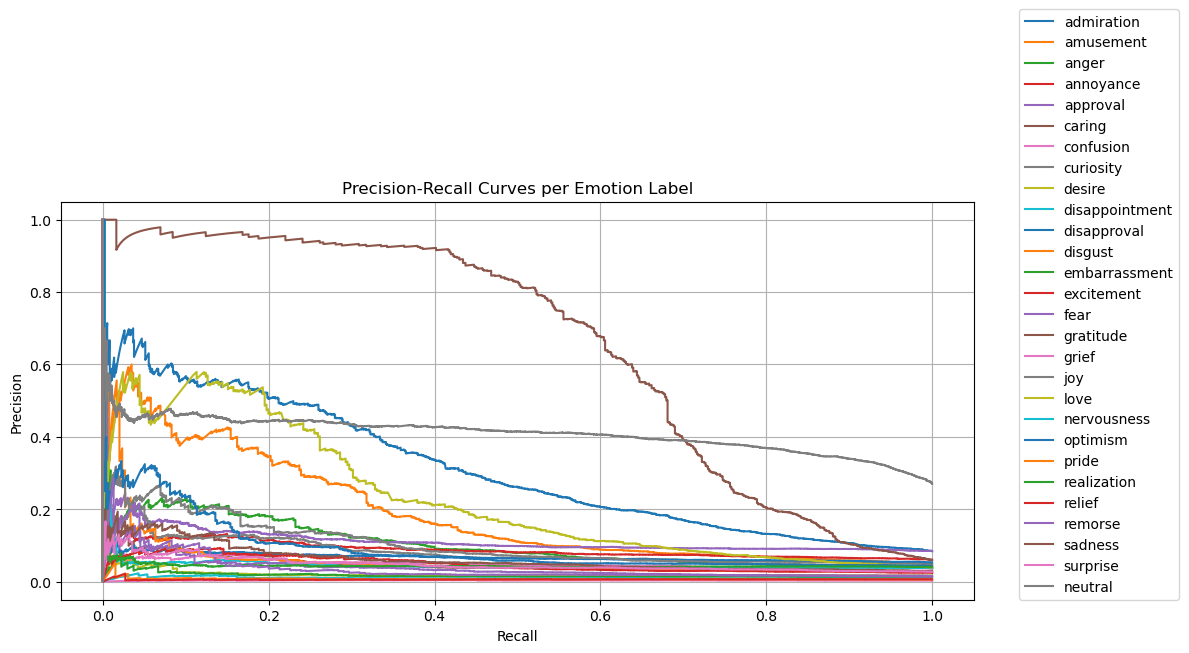

In [ ]:
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    precision_recall_curve
)
import matplotlib.pyplot as plt

# Evaluation Metrics

# F1, Precision, Recall (Micro and Macro)
print("Micro F1 Score:", f1_score(y_test, y_pred, average='micro'))
print("Macro F1 Score:", f1_score(y_test, y_pred, average='macro'))

print("Micro Precision:", precision_score(y_test, y_pred, average='micro'))
print("Macro Precision:", precision_score(y_test, y_pred, average='macro'))

print("Micro Recall:", recall_score(y_test, y_pred, average='micro'))
print("Macro Recall:", recall_score(y_test, y_pred, average='macro'))

# Classification Report

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=y_test.columns, zero_division=0))

# Precision-Recall Curves per Label

y_pred_proba = bow_nb_pipeline.predict_proba(X_test)

plt.figure(figsize=(12, 6))
for i, label in enumerate(y_test.columns):
    precision, recall, _ = precision_recall_curve(y_test.iloc[:, i], y_pred_proba[:, i])
    plt.plot(recall, precision, label=label)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves per Emotion Label")
plt.legend(loc="lower left", bbox_to_anchor=(1.05, 0), borderaxespad=0.)
plt.grid(True)
plt.tight_layout()
plt.show()


The baseline Multinomial Naive Bayes model was evaluated using the metrics as mentioned in the evaluation methodology section. 

As seen from the table above, the Multinomial Naive Bayes model achieves a macro F1-score of approximately 0.047, with micro F1 at 0.112. Precision is notably higher than recall, particularly at the micro level (0.494 vs 0.063), suggesting the model ignores subtle or overlapping emotional cues to avoid false alarms

Since this model serves as the baseline, its macro F1-score establishes the minimum threshold that more advanced models must exceed to demonstrate meaningful improvement in handling multi-label emotional classification under imbalanced conditions.

The classification report provides additional insight by detailing macro and micro precision, recall, and F1-scores per label. It also includes a support column, which indicates the number of true instances per emotion. In this dataset, support ranges from over 900 (for labels like admiration) to just 31 (for rare emotions such as grief), reinforcing the dataset’s severe imbalance. This imbalance can bias models toward dominant labels, making macro-averaged metrics a more appropriate evaluation choice.

The precision-recall(PR) curve plot shows how precision and recall trade off for each emotion as the decision threshold varies. Most emotion labels display low and flat PR curves, indicating the model struggles to achieve meaningful recall without sacrificing precision. However, a few labels like neutral or caring maintain relatively high precision across broader recall ranges, likely due to their higher support in the training data. In contrast, rarer labels like embarrassment, grief, or realization show near-zero precision or steep drop-offs, confirming the model’s inability to learn meaningful patterns for them.

## Statistical model

Logistic Regression combined with TF-IDF vectorization was chosen as the statistical model because it fits the structure and challenges of the GoEmotions dataset particularly well. The dataset consists of short, informal text messages that often contain multiple overlapping emotional labels. These texts are high in lexical variety, yet sparse in terms of word count, which makes feature extraction a critical step.

TF-IDF (Term Frequency–Inverse Document Frequency) addresses this by transforming each sentence into a high-dimensional vector that highlights informative, emotion-related words while downplaying common or unimportant terms. This reduces noise and helps preserve subtle emotional cues that are crucial for classification. Since TF-IDF produces sparse feature representations, it aligns with Logistic Regression's strength in handling large numbers of features efficiently.

Logistic Regression is also effective in multilabel classification problems like GoEmotions, where each instance can belong to multiple classes. Using the One-vs-Rest (OvR) strategy, Logistic Regression fits a separate binary classifier for each emotion label. This allows the model to treat each emotion independently and handle co-occurrence without assuming mutual exclusivity between labels, which is essential in emotion recognition tasks.

Moreover, Logistic Regression does not assume feature independence, unlike Naive Bayes. This makes it more capable of capturing nuanced word combinations and learning more flexible decision boundaries

However, Logistic Regression also has limitations in the context of multi-label emotion classification. Since it is a linear model, it may struggle to capture complex, non-linear relationships between words and emotions especially when emotional expression is implicit or context-dependent. Additionally, because TF-IDF representations lack semantic understanding, the model is unable to leverage similarities between words with related meanings (e.g. "joyful" and "happy" are treated as entirely separate features). This can limit the model's generalization ability, particularly for less frequent or nuanced emotion labels. Finally, performance may degrade on noisy or colloquial language, which is common in Reddit comments, due to the model's dependence on exact word forms rather than learned contextual patterns.

In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

class_weight='balanced' is used to address the class imbalance in the GoEmotions dataset. Without this adjustment, the model could become biased toward predicting emotion labels that occur more frequently, while neglecting less common emotions such as "grief" or "remorse". By assigning higher weight to minority classes, the balanced option ensures that each emotion label is treated more equally during training, regardless of how often it appears in the dataset. This improves the model’s ability to detect underrepresented emotions and helps achieve fairer performance across all labels.



'liblinear' is used because it is suitable for sparse and high-dimensional data, which is exactly what results from applying TF-IDF to short text inputs like those in the GoEmotions dataset. Each comment is converted into a vector with potentially tens of thousands of dimensions, one for each unique word in the corpus, but only a few non-zero values per sample. This makes the data extremely sparse

In [ ]:
# using the ifidf to vectorise and then using the onevsrest classifier for multilabel
tfidf_lr_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf', OneVsRestClassifier(LogisticRegression(solver='liblinear', max_iter=1000,class_weight='balanced')))
])


To reduce training time, the dataset was downsampled to 30% using train_test_split. The original training process was too time-consuming, taking over 2.5 hours without completion. By using a smaller subset, model tuning and evaluation became significantly faster while still maintaining representative samples.


In [21]:
from sklearn.model_selection import train_test_split

# Reduce to 30% of the dataset for quicker training
X_small, _, y_small, _ = train_test_split(
    X_train, y_train, 
    train_size=0.3, 
    random_state=22
)

### Hyperparameter Tuning and Model Fitting

To improve model performance, a grid search with 5-fold cross-validation was used to tune the hyperparameters of the Logistic Regression classifier. Specifically, the regularization strength C and the type of penalty (l1 or l2) were explored. The model was evaluated using macro-averaged F1 score to ensure fair performance across all emotion labels, including the minority classes.

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, f1_score

f1_macro_scorer = make_scorer(f1_score, average='macro', zero_division=0)

param_grid = {
    'clf__estimator__C': [0.01, 0.1, 1, 10],
    'clf__estimator__penalty': ['l1', 'l2']
}

grid = GridSearchCV(
    tfidf_lr_pipeline,
    param_grid,
    scoring=f1_macro_scorer,
    cv=5,
    verbose=1,
    n_jobs=-1
)

grid.fit(X_small, y_small)


Fitting 5 folds for each of 8 candidates, totalling 40 fits


In [ ]:
print("Best Parameters:", grid.best_params_)
print("Best Macro F1 Score (CV):", grid.best_score_)



Best Parameters: {'clf__estimator__C': 1, 'clf__estimator__penalty': 'l2'}
Best Macro F1 Score (CV): 0.2811690818584826


### Logistic Model Prediction

In [ ]:
# Retrieving the best performing logistic regression model from the grid search and making predictions on the test set
best_logistic_model = grid.best_estimator_
y_pred = best_logistic_model.predict(X_test)

### Results and Evaluation of Statistical Model

Micro F1 Score: 0.32437254381946623
Macro F1 Score: 0.2772538434468547
Micro Precision: 0.2417610062893082
Macro Precision: 0.21457521945749786
Micro Recall: 0.4927483152651626
Macro Recall: 0.4102286444115881

Classification Report:
                precision    recall  f1-score   support

    admiration       0.38      0.62      0.47       958
     amusement       0.49      0.72      0.58       519
         anger       0.21      0.45      0.28       435
     annoyance       0.15      0.38      0.22       695
      approval       0.15      0.35      0.21       966
        caring       0.13      0.40      0.20       322
     confusion       0.12      0.30      0.17       416
     curiosity       0.10      0.26      0.15       559
        desire       0.13      0.41      0.20       190
disappointment       0.10      0.28      0.15       423
   disapproval       0.13      0.36      0.19       604
       disgust       0.18      0.36      0.24       300
 embarrassment       0.11      0.23  

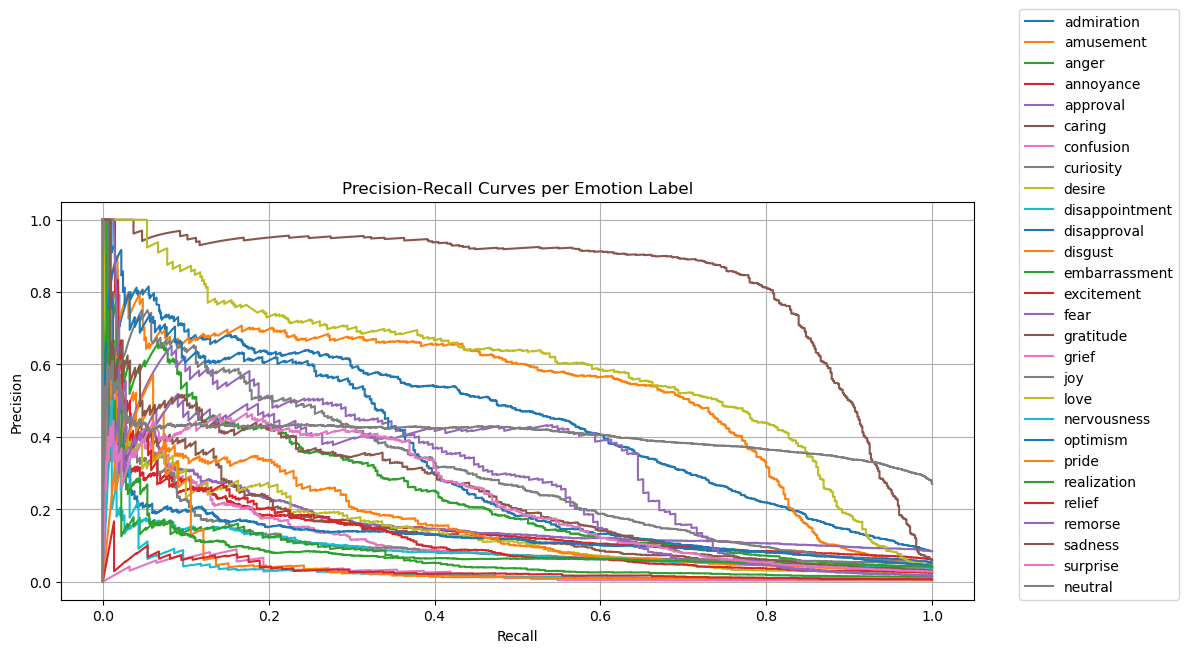

In [ ]:
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    precision_recall_curve
)
import matplotlib.pyplot as plt

# Evaluation Metrics

# F1, Precision, Recall (Micro and Macro)
print("Micro F1 Score:", f1_score(y_test, y_pred, average='micro'))
print("Macro F1 Score:", f1_score(y_test, y_pred, average='macro'))

print("Micro Precision:", precision_score(y_test, y_pred, average='micro'))
print("Macro Precision:", precision_score(y_test, y_pred, average='macro'))

print("Micro Recall:", recall_score(y_test, y_pred, average='micro'))
print("Macro Recall:", recall_score(y_test, y_pred, average='macro'))

# Classification Report

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=y_test.columns, zero_division=0))

# recision-Recall Curves per Label

y_pred_proba = best_logistic_model.predict_proba(X_test) 

plt.figure(figsize=(12, 6))
for i, label in enumerate(y_test.columns):
    precision, recall, _ = precision_recall_curve(y_test.iloc[:, i], y_pred_proba[:, i])
    plt.plot(recall, precision, label=label)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves per Emotion Label")
plt.legend(loc="lower left", bbox_to_anchor=(1.05, 0), borderaxespad=0.)
plt.grid(True)
plt.tight_layout()
plt.show()

The Logistic Regression model combined with TF-IDF vectorization produced a macro F1 score of 0.277 and a micro F1 score of 0.324, indicating moderate overall performance in the multilabel classification task. The macro precision was 0.21 and macro recall was 0.41.

The classification report shows that certain emotion labels like amusement and admiration achieved relatively high F1 scores of 0.58 and 0.47, respectively. These emotions also have relatively large support values, which means the model had more examples to learn from. On the other hand, emotions like disappointment, curiosity, and embarrassment yielded low F1 scores around 0.15, suggesting difficulty in capturing less represented or more ambiguous emotions.

The precision-recall curve visualization further supports this. Emotions such as gratitude and amusement maintain relatively high precision across a wide range of recall, indicating that the model can confidently identify these emotions. In contrast, many curves remain low and flat, reflecting the model's struggle with precision on less frequent or overlapping labels. These findings suggest that while the model can effectively capture well-represented and clearly expressed emotions, it still faces challenges in identifying subtle or rare labels in the multilabel emotion space.

## Modern Model

The Convolutional Neural Network (CNN) was selected as the deep learning model because of its effectiveness in capturing local patterns in sequential data such as text. In natural language processing (NLP), CNNs are particularly strong at extracting n-gram features, meaning they can detect groups of adjacent words. This helps in identifying emotionally relevant phrases or expressions regardless of their position in the sentence. This characteristic makes CNNs well-suited for emotion detection, where subtle cues like “very disappointed” or “really happy” often carry the emotional signal.

Unlike traditional models that rely on manually engineered features, CNNs learn these features automatically through convolutional filters. This allows the model to recognize nuanced and overlapping emotional cues that are difficult to represent using simpler techniques like TF-IDF. In addition, CNNs are computationally efficient and perform well on short texts, which is a common structure in the GoEmotions dataset where each input is typically a single sentence or comment.

GloVe was chosen for its ability to capture global semantic relationships between words, which helps in detecting subtle emotional cues in short texts like those in the GoEmotions dataset. Unlike Word2Vec, which focuses only on local context, GloVe offers a broader understanding of word meaning. It is also more lightweight than models like BERT, making it efficient to use without sacrificing quality. This makes GloVe a suitable and practical choice for emotion classification in social media-style text.

To convert words into dense numerical vectors, the model uses pre-trained GloVe embeddings that were trained on Twitter data. This specific version was chosen because the GoEmotions dataset contains short, informal, and conversational texts that closely resemble tweets. GloVe Twitter embeddings are able to capture slang, abbreviations, and emotional tone commonly found in social media, which matches the vocabulary and context of this dataset. Initializing the embedding layer with GloVe vectors enables the model to benefit from semantic relationships learned from millions of tweets, improving its ability to recognize emotional expressions in similar text.

In combination, the CNN architecture and Twitter-trained GloVe embeddings form a deep learning pipeline that fits the GoEmotions dataset well. The model leverages domain-specific word semantics and local phrase-level patterns to improve its ability to classify multiple emotion labels in each input.

However, the model does have limitations. CNNs primarily focus on local context and are not designed to capture long-range dependencies or sentence-level structure. This can be a drawback when emotional meaning depends on broader context, negation, or sarcasm. Additionally, because the GloVe embeddings are fixed and not fine-tuned during training, the model may not fully adapt to domain-specific nuances or newly emerging expressions not well represented in the pretrained vectors. The model also tends to require significantly more computational resources both in terms of training time and memory usage compared to traditional statistical models such as Logistic Regression or Naive Bayes, which are more lightweight and faster to train. Finally, the model's performance is influenced by class imbalance and overlapping emotions in the multilabel setting, which can challenge its ability to distinguish subtle or co-occurring emotional states.

### Modern model data preprocessing

Because the preprocessing requirements for modern deep learning models differ significantly from those of traditional statistical models, a separate DataFrame is created to cater specifically to the needs of the CNN-based model. Unlike traditional models, which benefit from techniques like stopword removal and lemmatization, modern models such as Convolutional Neural Networks (CNNs) process text as sequences of dense word embeddings. As a result, their preprocessing pipeline must preserve more of the original linguistic and syntactic information.

In contrast to traditional statistical models, stopwords are retained in the CNN model. This is because Convolutional Neural Networks treat text as a sequence of word embeddings rather than isolated features. Removing stopwords can disrupt the semantic meaning of the sentence, which is crucial for a CNN to detect meaningful patterns using convolutional filters.

Similar to stopwords, lemmatization is not applied in the CNN model. Lemmatization reduces words to their base or dictionary form, which is useful in traditional models like Logistic Regression to reduce sparsity. However, for CNNs using word embeddings like GloVe, each word (in its original form) is mapped to a dense vector that already captures semantic meaning and relationships.

Applying lemmatization could potentially strip away subtle linguistic variations that help the model learn contextual nuances especially in emotion-rich data where word forms like "crying" versus "cried" may convey different emotional intensities or contexts. By keeping the original word forms intact, the model benefits from the full richness of pretrained embeddings and can better learn patterns from word order and phrasing.

Thus, both stopwords and lemmatization are intentionally left untouched in preprocessing to preserve the natural sentence structure and optimize the CNN’s ability to detect local emotional patterns through convolutional filters.

In [ ]:
# making a copy of the dataframe
df_modern = df.copy()
# dropping unnecessary columns
df_modern = df_modern[df_modern['example_very_unclear'] != True]
modern_columns_to_drop = [
    'text', 'id', 'example_very_unclear',
    'author', 'subreddit', 'parent_id', 'link_id',
    'created_utc', 'rater_id'
]

df_modern = df_modern.drop(columns=modern_columns_to_drop)
df_modern

,admiration,amusement,anger,annoyance,approval,caring,confusion,curiosity,desire,disappointment,...,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral,cleaned_text
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,that game hurt
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,you do right if you dont care then fuck em
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,man i love reddit
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,was nowhere near them he was by the falcon
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,right considering its such an important docume...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211086,1,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,he called to the steelers and was outspoken wi...
211088,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,i didnt even notice that one i noticed the bot...
211094,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,thanks
211095,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,everyone likes


In [ ]:
# splitting to text and labels
texts = df_modern['cleaned_text'].tolist()
labels = df_modern.drop(columns=['cleaned_text'])


### Modern Model Tokenization

The input texts are first tokenized using Keras’ Tokenizer, which converts words into integer sequences based on frequency. These sequences are then padded to a fixed length of 100 using pad_sequences, ensuring all inputs have the same shape, which is required by the CNN. The resulting X_modern contains the padded numerical input, while y_modern holds the corresponding multilabel emotion target

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

tokenizer = Tokenizer()
tokenizer.fit_on_texts(texts)
sequences = tokenizer.texts_to_sequences(texts)

max_len = 100
X_modern = pad_sequences(sequences, maxlen=max_len)
y_modern = labels.values


2025-06-22 16:32:23.918696: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-06-22 16:32:24.223473: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-06-22 16:32:24.344897: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-06-22 16:32:24.375226: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-06-22 16:32:24.611435: I tensorflow/core/platform/cpu_feature_guar

### Loading and initialising Pretrained GloVe Embeddings

The pre-trained GloVe Twitter embeddings with 100 dimensions (glove.twitter.27B.100d.txt) is then loaded in. Each line is split into a word and its corresponding 100-dimensional vector, which is stored in the embedding_index dictionary. The 100d version was chosen as it offers a strong balance between semantic richness and computational efficiency. Higher-dimensional embeddings like 200d or 300d may capture more nuance but come at the cost of longer training time and increased risk of overfitting, especially for smaller datasets. The 100d embedding is well-suited for short, informal text like the social media-based GoEmotions dataset.

In [ ]:
embedding_index = {}
glove_path = "glove.twitter.27B.100d.txt"

with open(glove_path, encoding="utf8") as f:
    for line in f:
        values = line.strip().split()
        word = values[0]
        vector = [float(val) for val in values[1:]]
        embedding_index[word] = vector


This code initializes a matrix and fills it with GloVe word vectors for each word in the tokenizer’s vocabulary. If a word has a matching GloVe vector, it’s added to the matrix; otherwise, the row stays as zeros. This prepares the embedding weights for the CNN model.

In [ ]:
import numpy as np

embedding_dim = 100
vocab_size = len(tokenizer.word_index) + 1

# Initialize embedding matrix with zeros
embedding_matrix = np.zeros((vocab_size, embedding_dim))

# For each word in the tokenizer vocabulary, check if a glove embedding exists
# If it does, assign the corresponding vector to the embedding matrix at the word's index
for word, i in tokenizer.word_index.items():
    vector = embedding_index.get(word)
    if vector is not None:
        embedding_matrix[i] = vector


### Hyperparameter Tuning with Keras Tuner

To preserve the semantic structure of the input, the model’s embedding layer is kept frozen during training(trainable = false), ensuring that pretrained linguistic knowledge remains intact throughout learning.

The model is wrapped in a Keras Tuner build_model function to support hyperparameter tuning. It searches over the number of filters (64, 128, 256), kernel sizes (3, 5, 7), dense layer units (64, 128, 256), and dropout rates (0.2, 0.3, 0.5) to find the best configuration for multilabel emotion classification.

In [ ]:

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout
from keras_tuner import RandomSearch

# defining a function that builds a CNN model with tunable hyperparamters
def build_model(hp):
    model = Sequential()
    
    # adding the embedding layer using the pretrained glove embeddings
    # Setting trainable to false to keep embeddings fixed 
    model.add(Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        input_length=max_len,
        trainable=False  # Freeze embeddings
    ))
    
    # adding a 1D convolutional layer
    model.add(Conv1D(
        filters=hp.Choice('filters', values=[64, 128, 256]),
        kernel_size=hp.Choice('kernel_size', values=[3, 5, 7]),
        activation='relu'
    ))
    
    # this reduces the output of the convolution
    model.add(GlobalMaxPooling1D())
    
    model.add(Dense(
        units=hp.Choice('dense_units', values=[64, 128, 256]),
        activation='relu'
    ))
    
    # adding dropout for regularization
    model.add(Dropout(
        hp.Choice('dropout', values=[0.2, 0.3, 0.5])
    ))
    
    # output layer with sigmoid activation for multilabel classification
    model.add(Dense(y_modern.shape[1], activation='sigmoid'))

    #binary crossentropy loss is used becuase it is suitable for multilabel task
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    return model


Since Keras models typically save the best checkpoint based on validation loss or accuracy, which can be misleading in multi-label or imbalanced tasks, I implemented a custom callback called F1MacroCallback. This callback calculates the macro F1-score at the end of each epoch, tracks the best-performing model based on F1, and restores those weights after training. This ensures that the final model is the one that performs best on the metric that truly matters for my task.

In [ ]:
from sklearn.metrics import f1_score
from tensorflow.keras.callbacks import Callback
import numpy as np

class F1MacroCallback(Callback):
    def __init__(self, validation_data):
        super().__init__()
        self.X_val, self.y_val = validation_data
        self.best_f1 = 0
        self.best_weights = None

    def on_epoch_end(self, epoch, logs=None):
        y_pred = self.model.predict(self.X_val)
        y_pred_binary = (y_pred > 0.5).astype(int)
        f1 = f1_score(self.y_val, y_pred_binary, average='macro', zero_division=0)

        print(f"\nEpoch {epoch + 1} — F1 Macro: {f1:.4f}")
        
        # Save best weights manually based on F1
        if f1 > self.best_f1:
            self.best_f1 = f1
            self.best_weights = self.model.get_weights()

    def on_train_end(self, logs=None):
        # Load best weights after training
        if self.best_weights:
            self.model.set_weights(self.best_weights)


A training pipeline was constructed for a multilabel CNN model using GloVe embeddings, with hyperparameter tuning handled by Keras Tuner's RandomSearch. The dataset is first split into training and test sets, and the tuner explores different model configurations to find the best-performing one. During training, a custom callback is used to ensure model evaluation aligns with the task's performance goals. Once tuning is complete, the best model and its hyperparameters are retrieved, and the model is evaluated on the test set using both accuracy and macro F1-score to provide a clearer picture of its generalization performance.

In [ ]:
# Split into train and test
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

X_train, X_test, y_train, y_test = train_test_split(
    X_modern, y_modern, test_size=0.2, random_state=22
)

# setting up the tuner
from keras_tuner import RandomSearch

tuner = RandomSearch(
    build_model,                         
    objective='val_accuracy',            
    max_trials=10,                       
    executions_per_trial=1,              
    directory='tuner_results_3',
    project_name='glove_multilabel_cnn_v5',
    overwrite=True
)
# call back is used to check which model has the highest f1 for each epoch
f1_callback = F1MacroCallback(validation_data=(X_test, y_test))

# running the hyperparameter search. Each trial will run for 15 epochs
tuner.search(
    X_train, y_train,
    epochs=15,
    batch_size=32,
    validation_split=0.2,
    callbacks=[f1_callback],
    verbose=2
)

# Get the best model and its hyperparameters
best_model = tuner.get_best_models(num_models=1)[0]
best_hps = tuner.get_best_hyperparameters(1)[0]

print("Best hyperparameters found:")
print(best_hps.values)

# Evaluate the best model on the unseen test set
loss, acc = best_model.evaluate(X_test, y_test)
print("Test accuracy:", acc)

# Evaluate F1 Macro on test set
y_pred = best_model.predict(X_test)
y_pred_binary = (y_pred > 0.5).astype(int)
f1 = f1_score(y_test, y_pred_binary, average='macro', zero_division=0)
print("Test F1 Macro:", f1)


Trial 10 Complete [00h 01m 26s]
val_accuracy: 0.4081072211265564

Best val_accuracy So Far: 0.41854333877563477
Total elapsed time: 00h 15m 10s


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:576: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Best hyperparameters found:
{'filters': 256, 'kernel_size': 3, 'dense_units': 128, 'dropout': 0.2}
356/356 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4223 - loss: 0.1226
Test accuracy: 0.41527509689331055
356/356 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Test F1 Macro: 0.14862447698236483


After hyperparameter tuning, the top 10 models are evaluated using various threshold values to identify the combination that yields the highest macro F1-score. This ensures the selected model and threshold are best suited for the multilabel classification task.

In [ ]:
from sklearn.metrics import f1_score
import numpy as np

top_models = tuner.get_best_models(num_models=10)
best_f1 = 0
best_model_by_f1 = None
best_threshold = 0.5

# Try multiple thresholds to find the best one
thresholds_to_try = np.arange(0.1, 0.9, 0.1)

for i, model in enumerate(top_models):
    print(f"\nModel #{i+1} Evaluation:")
    y_pred_prob = model.predict(X_test)
    
    for thresh in thresholds_to_try:
        y_pred = (y_pred_prob > thresh).astype(int)
        f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)

        print(f"  Threshold {thresh:.2f} → F1 Macro: {f1:.4f}")

        if f1 > best_f1:
            best_f1 = f1
            best_model_by_f1 = model
            best_threshold = thresh

print("\nBest F1 Macro Score:", best_f1)
print("Best threshold:", best_threshold)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:576: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))



Model #1 Evaluation:
356/356 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
  Threshold 0.10 → F1 Macro: 0.2934
  Threshold 0.20 → F1 Macro: 0.2610
  Threshold 0.30 → F1 Macro: 0.2224
  Threshold 0.40 → F1 Macro: 0.1875
  Threshold 0.50 → F1 Macro: 0.1486
  Threshold 0.60 → F1 Macro: 0.1064
  Threshold 0.70 → F1 Macro: 0.0741
  Threshold 0.80 → F1 Macro: 0.0513

Model #2 Evaluation:
356/356 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
  Threshold 0.10 → F1 Macro: 0.2867
  Threshold 0.20 → F1 Macro: 0.2784
  Threshold 0.30 → F1 Macro: 0.2368
  Threshold 0.40 → F1 Macro: 0.1946
  Threshold 0.50 → F1 Macro: 0.1518
  Threshold 0.60 → F1 Macro: 0.1132
  Threshold 0.70 → F1 Macro: 0.0727
  Threshold 0.80 → F1 Macro: 0.0456

Model #3 Evaluation:
356/356 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
  Threshold 0.10 → F1 Macro: 0.3050
  Threshold 0.20 → F1 Macro: 0.2812
  Threshold 0.30 → F1 Macro: 0.2387
  Threshold 0.40 → F1 Macro: 0.2023
  Threshold 0.50 → F1 Macro: 0.1640
  Threshold 0.60 → F1 Macro: 0.1247
  Threshold 0.70 → 

As can be seen the best f1 macro score is 0.3 and the best threshold is 0.1. Thus the parameters that is used to get the best F1 macro score will be the best model.

### Results and evaluation of Modern Model

356/356 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Micro F1 Score: 0.39351590322976787
Macro F1 Score: 0.3050095545124445
Micro Precision: 0.29601300668809816
Macro Precision: 0.2718138515038121
Micro Recall: 0.5868004687957808
Macro Recall: 0.4085887638250629

Classification Report:
                precision    recall  f1-score   support

    admiration       0.36      0.75      0.49       958
     amusement       0.45      0.78      0.57       519
         anger       0.28      0.38      0.32       435
     annoyance       0.18      0.51      0.26       695
      approval       0.19      0.40      0.25       966
        caring       0.18      0.42      0.25       322
     confusion       0.21      0.29      0.24       416
     curiosity       0.28      0.48      0.35       559
        desire       0.20      0.35      0.25       190
disappointment       0.15      0.16      0.15       423
   disapproval       0.23      0.24      0.23       604
       disgust       0.17      0.46      0.25       

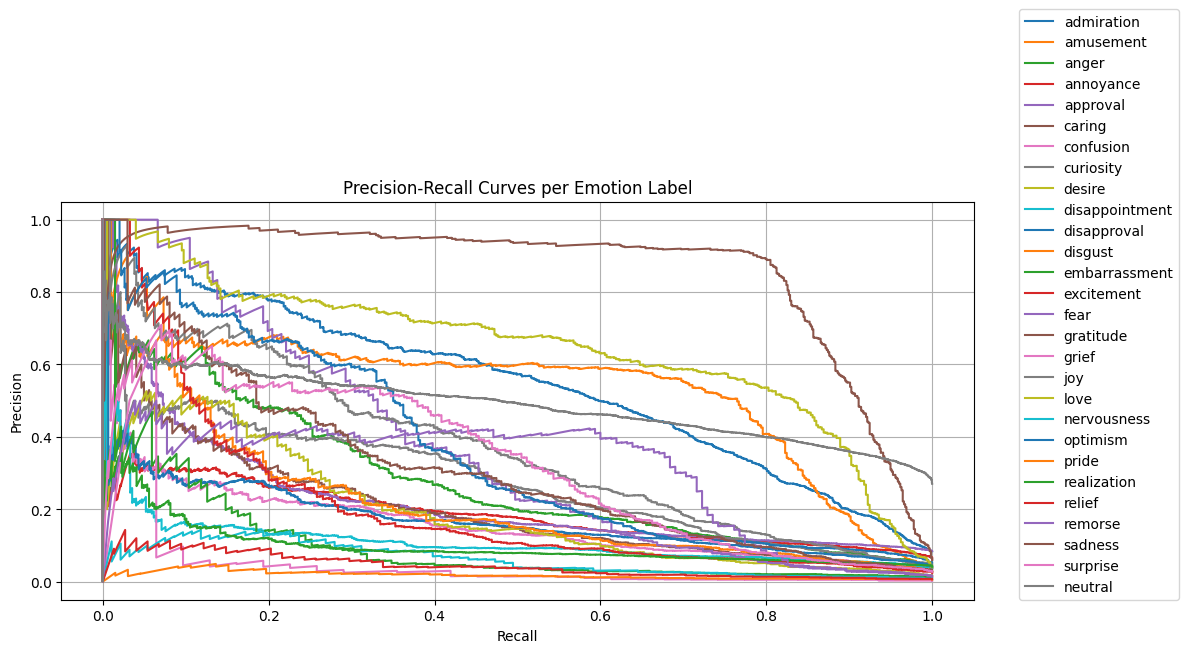

In [ ]:
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    precision_recall_curve
)
import matplotlib.pyplot as plt

# Predict using the best model and threshold
y_pred_prob = best_model_by_f1.predict(X_test)
y_pred = (y_pred_prob > best_threshold).astype(int)

# Evaluation Metrics
print("Micro F1 Score:", f1_score(y_test, y_pred, average='micro'))
print("Macro F1 Score:", f1_score(y_test, y_pred, average='macro'))

print("Micro Precision:", precision_score(y_test, y_pred, average='micro'))
print("Macro Precision:", precision_score(y_test, y_pred, average='macro'))

print("Micro Recall:", recall_score(y_test, y_pred, average='micro'))
print("Macro Recall:", recall_score(y_test, y_pred, average='macro'))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=labels.columns.tolist(), zero_division=0))

# Precision-Recall Curves per Label
plt.figure(figsize=(12, 6))
for i, label in enumerate(labels.columns.tolist()):
    precision, recall, _ = precision_recall_curve(y_test[:, i]
, y_pred_prob[:, i])
    plt.plot(recall, precision, label=label)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves per Emotion Label")
plt.legend(loc="lower left", bbox_to_anchor=(1.05, 0), borderaxespad=0.)
plt.grid(True)
plt.tight_layout()
plt.show()


The CNN model, enhanced with pre-trained GloVe Twitter embeddings, demonstrates solid multilabel classification performance across several key metrics. The model achieved a macro F1-score of 0.305 and a micro F1-score of 0.393, indicating that while its overall label-wise performance is moderate, it performs better when aggregating predictions across all samples.

The classification report further reflects this trend. Emotions with clearer linguistic patterns or more examples such as gratitude (F1: 0.76), neutral (F1: 0.48), and amusement (F1: 0.57) are recognized with relatively high recall and precision. In contrast, emotions like grief, relief, and pride yielded extremely low F1-scores or even zero, largely due to their limited support in the dataset and possibly ambiguous expressions.

The macro-averaged metrics (Precision: 0.272, Recall: 0.409, F1: 0.305) reveal that the model's ability to generalize across all classes, regardless of frequency, is modest. This highlights the challenge of learning rare or subtle emotions in a multilabel setting where overlap is common and class imbalance is severe.

The precision-recall curves provide additional insight into per-label behavior. Some classes, such as gratitude, maintain high precision even as recall increases, indicating strong confidence in predictions. However, many curves remain flat, though not as much as when compared to logistic regression.

Overall, the CNN model successfully captures many common and expressive emotions, particularly when they align with informal social media language. Nevertheless, its performance varies across emotion types due to class imbalance, subtle distinctions between emotions, and limitations in capturing broader contextual cues that may be necessary to disambiguate certain emotional expressions.

# Conclusions

## Performance Analysis and Comparative Discussion

In [ ]:
radar_data = {
    "Metric": [
        "Micro F1", "Macro F1", "Micro Precision", "Macro Precision", "Micro Recall", "Macro Recall"
    ],
    "Baseline (Multinomial NB - BoW)": [
        0.11116889871278117,
        0.04694962449807562,
        0.49421965317919075,
        0.198886971114453,
        0.06262818634632289,
        0.030220542911142883
    ],
    "Statistical Model (LogReg - TF-IDF)": [
        0.32437254381946623,
        0.2772538434468547,
        0.2417610062893082,
        0.21457521945749786,
        0.4927483152651626,
        0.41022864441115881
    ],
    "Deep Learning (CNN + GloVe)": [
        0.39351590322976787,
        0.3050095545124445,
        0.29601300668809816,
        0.2718138515038121,
        0.5868004687957808,
        0.4085887638250629
    ]
}

df_radar = pd.DataFrame(radar_data)
print(df_radar)


            Metric  Baseline (Multinomial NB - BoW)  \
0         Micro F1                         0.111169   
1         Macro F1                         0.046950   
2  Micro Precision                         0.494220   
3  Macro Precision                         0.198887   
4     Micro Recall                         0.062628   
5     Macro Recall                         0.030221   

   Statistical Model (LogReg - TF-IDF)  Deep Learning (CNN + GloVe)  
0                             0.324373                     0.393516  
1                             0.277254                     0.305010  
2                             0.241761                     0.296013  
3                             0.214575                     0.271814  
4                             0.492748                     0.586800  
5                             0.410229                     0.408589  


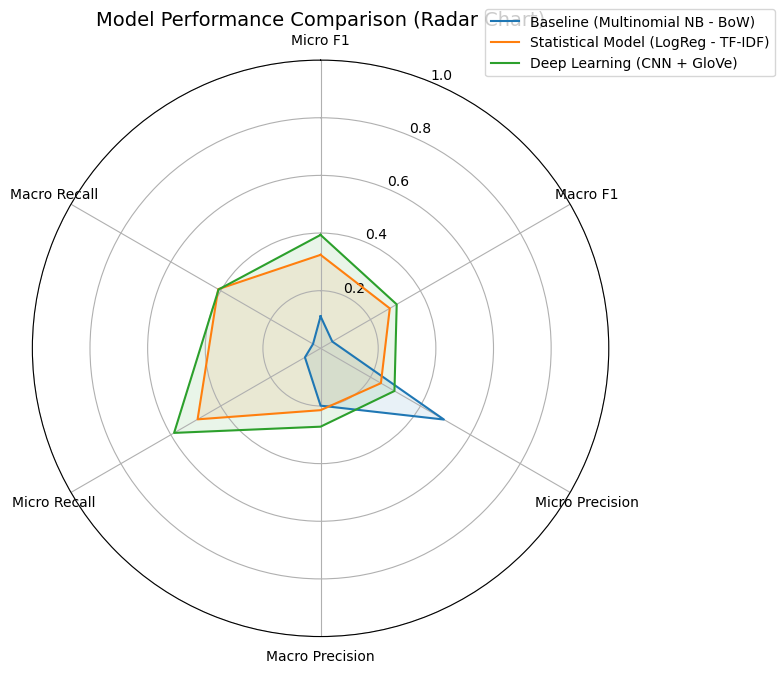

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
# radar chart
labels = df_radar['Metric'].tolist()
num_vars = len(labels)


angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

# Plot model
for model in df_radar.columns[1:]:
    values = df_radar[model].tolist()
    values += values[:1]  # close the loop
    ax.plot(angles, values, label=model)
    ax.fill(angles, values, alpha=0.1)

# Add labels
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), labels)
ax.set_title("Model Performance Comparison (Radar Chart)", size=14)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
ax.set_ylim(0, 1)

# Show plot
plt.tight_layout()
plt.show()


Overall, the radar chart shows that both the Logistic Regression and CNN + GloVe models consistently outperform the baseline Naive Bayes model across almost all metrics. The only exception is micro precision, where Naive Bayes surprisingly reports the highest value (0.494). This anomaly likely stems from how Naive Bayes treats features independently and tends to produce highly confident predictions only when there is strong word presence in the training data. As a result, it predicts fewer positive labels but with high certainty, which inflates precision at the cost of extremely low recall (0.067).

Between the two stronger models, the deep learning model outperforms Logistic Regression across all six radar metrics, showing improved generalization across both common and rare emotions. Higher macro and micro scores suggest the CNN is better at capturing emotional patterns both on a per-label basis and across overall predictions. For instance, a macro F1 increase from 0.277 to 0.305 may seem modest, but in a multilabel, imbalanced context like GoEmotions, such gains indicate the model is significantly more inclusive and accurate across diverse emotion categories.


In [ ]:
f1_bar_data = {
    "Average Type": ["Macro Avg", "Weighted Avg", "Samples Avg"],
    "Baseline (Multinomial NB)": [0.05, 0.10, 0.07],
    "Statistical Model (LogReg)": [0.28, 0.35, 0.34],
    "Deep Learning Model (CNN + GloVe)": [0.31, 0.38, 0.42]
}

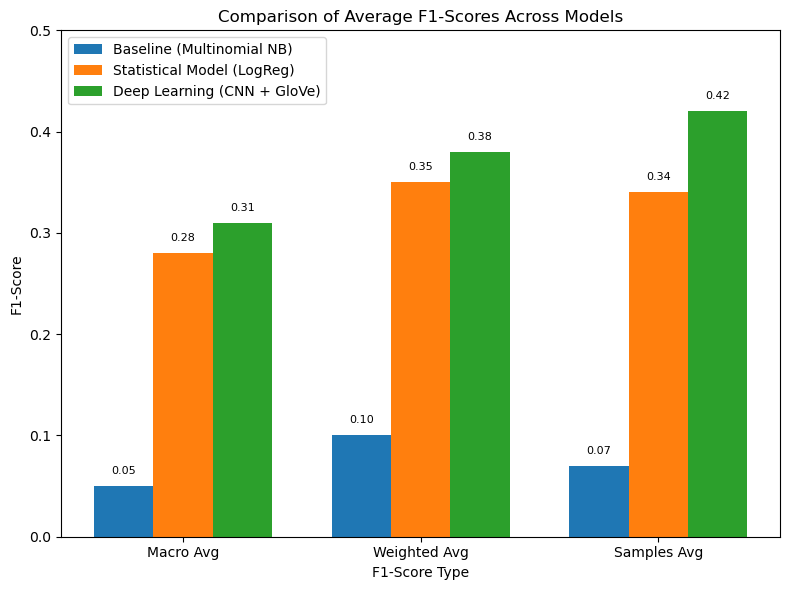

In [ ]:
df_bar = pd.DataFrame(f1_bar_data)

# Step 2: Plot setup
labels = df_bar["Average Type"]
x = np.arange(len(labels))  # label positions
width = 0.25  # width of each bar

fig, ax = plt.subplots(figsize=(8, 6))

# Step 3: Plot each model
ax.bar(x - width, df_bar["Baseline (Multinomial NB)"], width, label="Baseline (Multinomial NB)")
ax.bar(x, df_bar["Statistical Model (LogReg)"], width, label="Statistical Model (LogReg)")
ax.bar(x + width, df_bar["Deep Learning Model (CNN + GloVe)"], width, label="Deep Learning (CNN + GloVe)")

# Step 4: Customize plot
ax.set_xlabel("F1-Score Type")
ax.set_ylabel("F1-Score")
ax.set_title("Comparison of Average F1-Scores Across Models")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 0.5)
ax.legend(loc="upper left")

# Optional: Add value labels
for i in range(len(labels)):
    for j, model in enumerate(["Baseline (Multinomial NB)", "Statistical Model (LogReg)", "Deep Learning Model (CNN + GloVe)"]):
        score = df_bar[model][i]
        ax.text(x[i] + (j - 1) * width, score + 0.01, f"{score:.2f}", ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

Once again, both Logistic Regression and CNN + GloVe outperform the Naive Bayes baseline by a wide margin across all F1-score types. The bar chart illustrates this clearly across macro, weighted, and samples-averaged F1 scores. The macro average, which highlights per-class fairness regardless of frequency, shows CNN achieving 0.31, Logistic Regression 0.28, and Naive Bayes a distant 0.05. This reinforces CNN’s capability to detect both common and rare emotion labels more reliably.

The weighted average, which accounts for class imbalance, and the samples average, which evaluates multilabel accuracy per instance, further confirm CNN’s superiority in real-world performance. These higher scores reflect the model’s ability to learn meaningful emotional patterns using word embeddings trained on social media-style text.

Despite this, statistical models like Logistic Regression remain practical alternatives, especially in environments with limited computational resources. As shown in the bar chart, it comes close to the CNN model in macro (0.28 vs. 0.31) and weighted F1 (0.35 vs. 0.38), demonstrating that with strong feature engineering like TF-IDF, it can still deliver competitive performance. However, the consistent lead held by the CNN across all three F1 types reflects its greater representational capacity, particularly in modeling emotional nuance and context that statistical models struggle to capture.


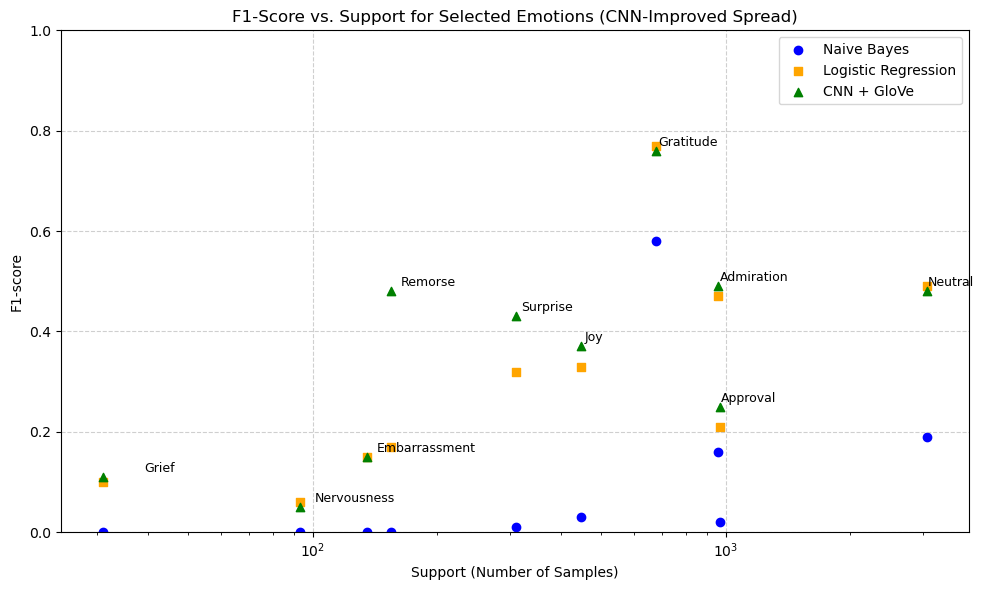

In [ ]:
import matplotlib.pyplot as plt

# Selected emotions and corresponding values
emotions = ['Grief', 'Nervousness', 'Embarrassment', 'Remorse', 'Surprise',
            'Joy', 'Gratitude', 'Admiration', 'Approval', 'Neutral']
support = [31, 93, 135, 155, 311, 446, 677, 958, 966, 3075]

# F1 scores for each model
f1_nb = [0.00, 0.00, 0.00, 0.00, 0.01, 0.03, 0.58, 0.16, 0.02, 0.19]
f1_log = [0.10, 0.06, 0.15, 0.17, 0.32, 0.33, 0.77, 0.47, 0.21, 0.49]
f1_cnn = [0.11, 0.05, 0.15, 0.48, 0.43, 0.37, 0.76, 0.49, 0.25, 0.48]

# Plotting
plt.figure(figsize=(10, 6))
plt.scatter(support, f1_nb, label='Naive Bayes', marker='o', color='blue')
plt.scatter(support, f1_log, label='Logistic Regression', marker='s', color='orange')
plt.scatter(support, f1_cnn, label='CNN + GloVe', marker='^', color='green')

# Annotate each CNN point with the emotion name
for i, emo in enumerate(emotions):
    plt.text(support[i] + 8, f1_cnn[i] + 0.01, emo, fontsize=9)

# Formatting
plt.title("F1-Score vs. Support for Selected Emotions (CNN-Improved Spread)")
plt.xlabel("Support (Number of Samples)")
plt.ylabel("F1-score")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.ylim(0, 1)
plt.xscale('log')
plt.tight_layout()
plt.show()


The scatter plot illustrates how F1-score varies by class frequency. CNN + GloVe shows the broadest spread and strongest performance across both high- and low-support emotion labels. It performs especially well on difficult, low-resource emotions like remorse and surprise, where Logistic Regression falls short and Naive Bayes fails completely. For frequent classes like gratitude, neutral, and admiration, all models perform reasonably, but CNN still leads.

This highlights CNN’s ability to not only predict common, well-represented emotions, but also generalize to rare and underrepresented ones, thanks to its use of pretrained embeddings and hierarchical pattern learning making it particularly suited for emotion detection in imbalanced, multilabel text data.

## Project Summary and Reflections

This project explored multilabel emotion classification using the GoEmotions dataset by implementing and evaluating three models: a baseline Multinomial Naive Bayes, a statistical Logistic Regression model with TF-IDF, and a deep learning CNN model with pretrained GloVe embeddings. Through this comparative approach, I gained valuable insight into the strengths, limitations, and practical trade-offs of different model types when applied to real-world emotion-rich text data.

The CNN + GloVe model consistently achieved the highest performance across all metrics, demonstrating its superior capacity to learn from both common and rare emotional expressions. Its ability to retain syntactic structure and leverage pretrained embeddings made it especially effective in handling short, informal sentences a common feature in the GoEmotions dataset. Logistic Regression, while less flexible, proved to be a competitive and resource-efficient alternative, offering strong results with interpretable outputs. Naive Bayes, though simple, struggled with nuance and imbalance, highlighting its limitations in complex multilabel tasks.

In terms of practicality, CNN training was the most time-consuming, requiring multiple epochs and extensive hyperparameter tuning to achieve optimal results. On CPU, training was prohibitively slow, and a GPU was essential to complete tuning and evaluation within a reasonable timeframe. Logistic Regression also became computationally intensive during hyperparameter search, particularly due to large feature matrices from TF-IDF and limited to CPU-only execution. Naive Bayes, on the other hand, trained almost instantly and required minimal resources, making it ideal for quick testing or low-power environments.

Each model type has situational value. Naive Bayes might suit educational or prototype systems. Logistic Regression offers a strong balance for lightweight, interpretable applications. CNNs are best for production systems demanding higher accuracy, such as mental health monitoring, emotion-aware chatbots, or social media moderation.

The pipeline is transferable to similar domains involving short-form user-generated content such as reviews, chat feedback, or survey responses. To improve this work, future research could explore transformer-based models like BERT, data augmentation for rare classes, or domain adaptation techniques. Incorporating user metadata or temporal context may further boost performance in dynamic, real-world settings.

Overall, the project delivered a robust, insightful classification system while deepening my understanding of NLP workflows, model selection, and evaluation.


# References

Bostan Bostan, L.-A.-M., Klinger, R., Institut für Maschinelle Sprachverarbeitung, & University of Stuttgart. (2018). An analysis of annotated corpora for emotion classification in text. In Proceedings of the 27th International Conference on Computational Linguistics (pp. 2104–2119) [Conference-proceeding]. https://aclanthology.org/C18-1179.pdf

Jadon, A. K., & Kumar, S. (n.d.). Emotion detection using Word2Vec and convolution neural networks. Indonesian Journal of Electrical Engineering and Computer Science, 33(3), 1812–1819. https://doi.org/10.11591/ijeecs.v33.i3.pp1812-1819

Stihec, J. (2024, August 14). Choose your AI weapon: deep learning or traditional machine learning. Shelf. https://shelf.io/blog/choose-your-ai-weapon-deep-learning-or-traditional-machine-learning